In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


✅  Loaded: job_dataset.csv  |  Shape: (17880, 18)

Train: 14304  |  Test: 3576
Fraud rate — train: 4.845%  | test: 4.838%


═════════════════════════════════════════════════════════════════
  🌲  MODEL 1 — Random Forest
═════════════════════════════════════════════════════════════════
  Training...

--- Random Forest (threshold=0.3) ---
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
        Fake       0.79      0.86      0.82       173

    accuracy                           0.98      3576
   macro avg       0.89      0.92      0.91      3576
weighted avg       0.98      0.98      0.98      3576

  ✅  Dashboard saved → dashboard_random_forest.png


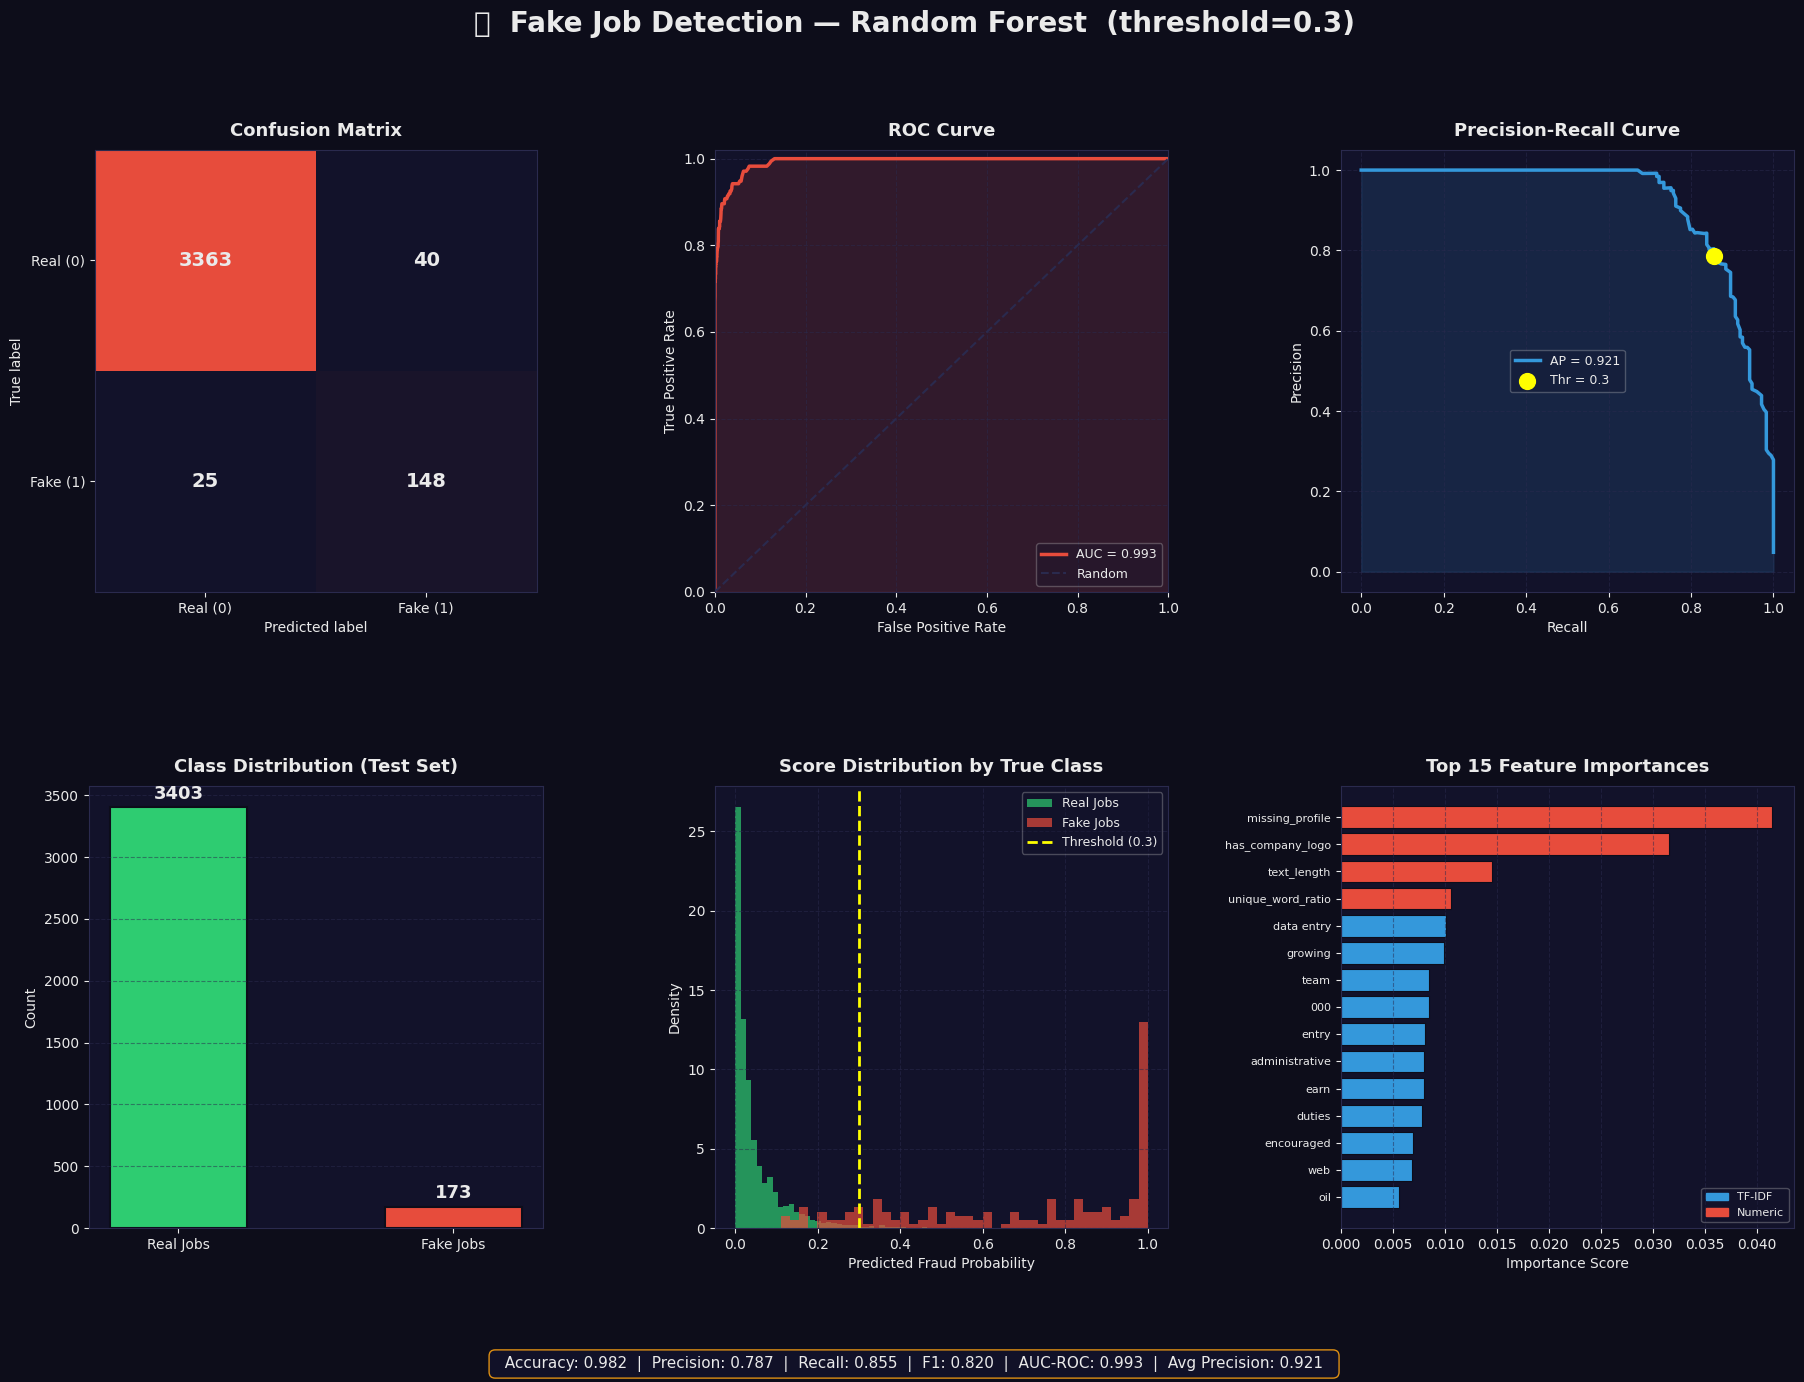

  Saved → rf_pipeline.pkl

═════════════════════════════════════════════════════════════════
  🚀  MODEL 2 — XGBoost
═════════════════════════════════════════════════════════════════
  scale_pos_weight = 19.64
  Training...

--- XGBoost (threshold=0.3) ---
              precision    recall  f1-score   support

        Real       0.99      0.95      0.97      3403
        Fake       0.48      0.90      0.62       173

    accuracy                           0.95      3576
   macro avg       0.74      0.92      0.80      3576
weighted avg       0.97      0.95      0.96      3576

  ✅  Dashboard saved → dashboard_xgboost.png


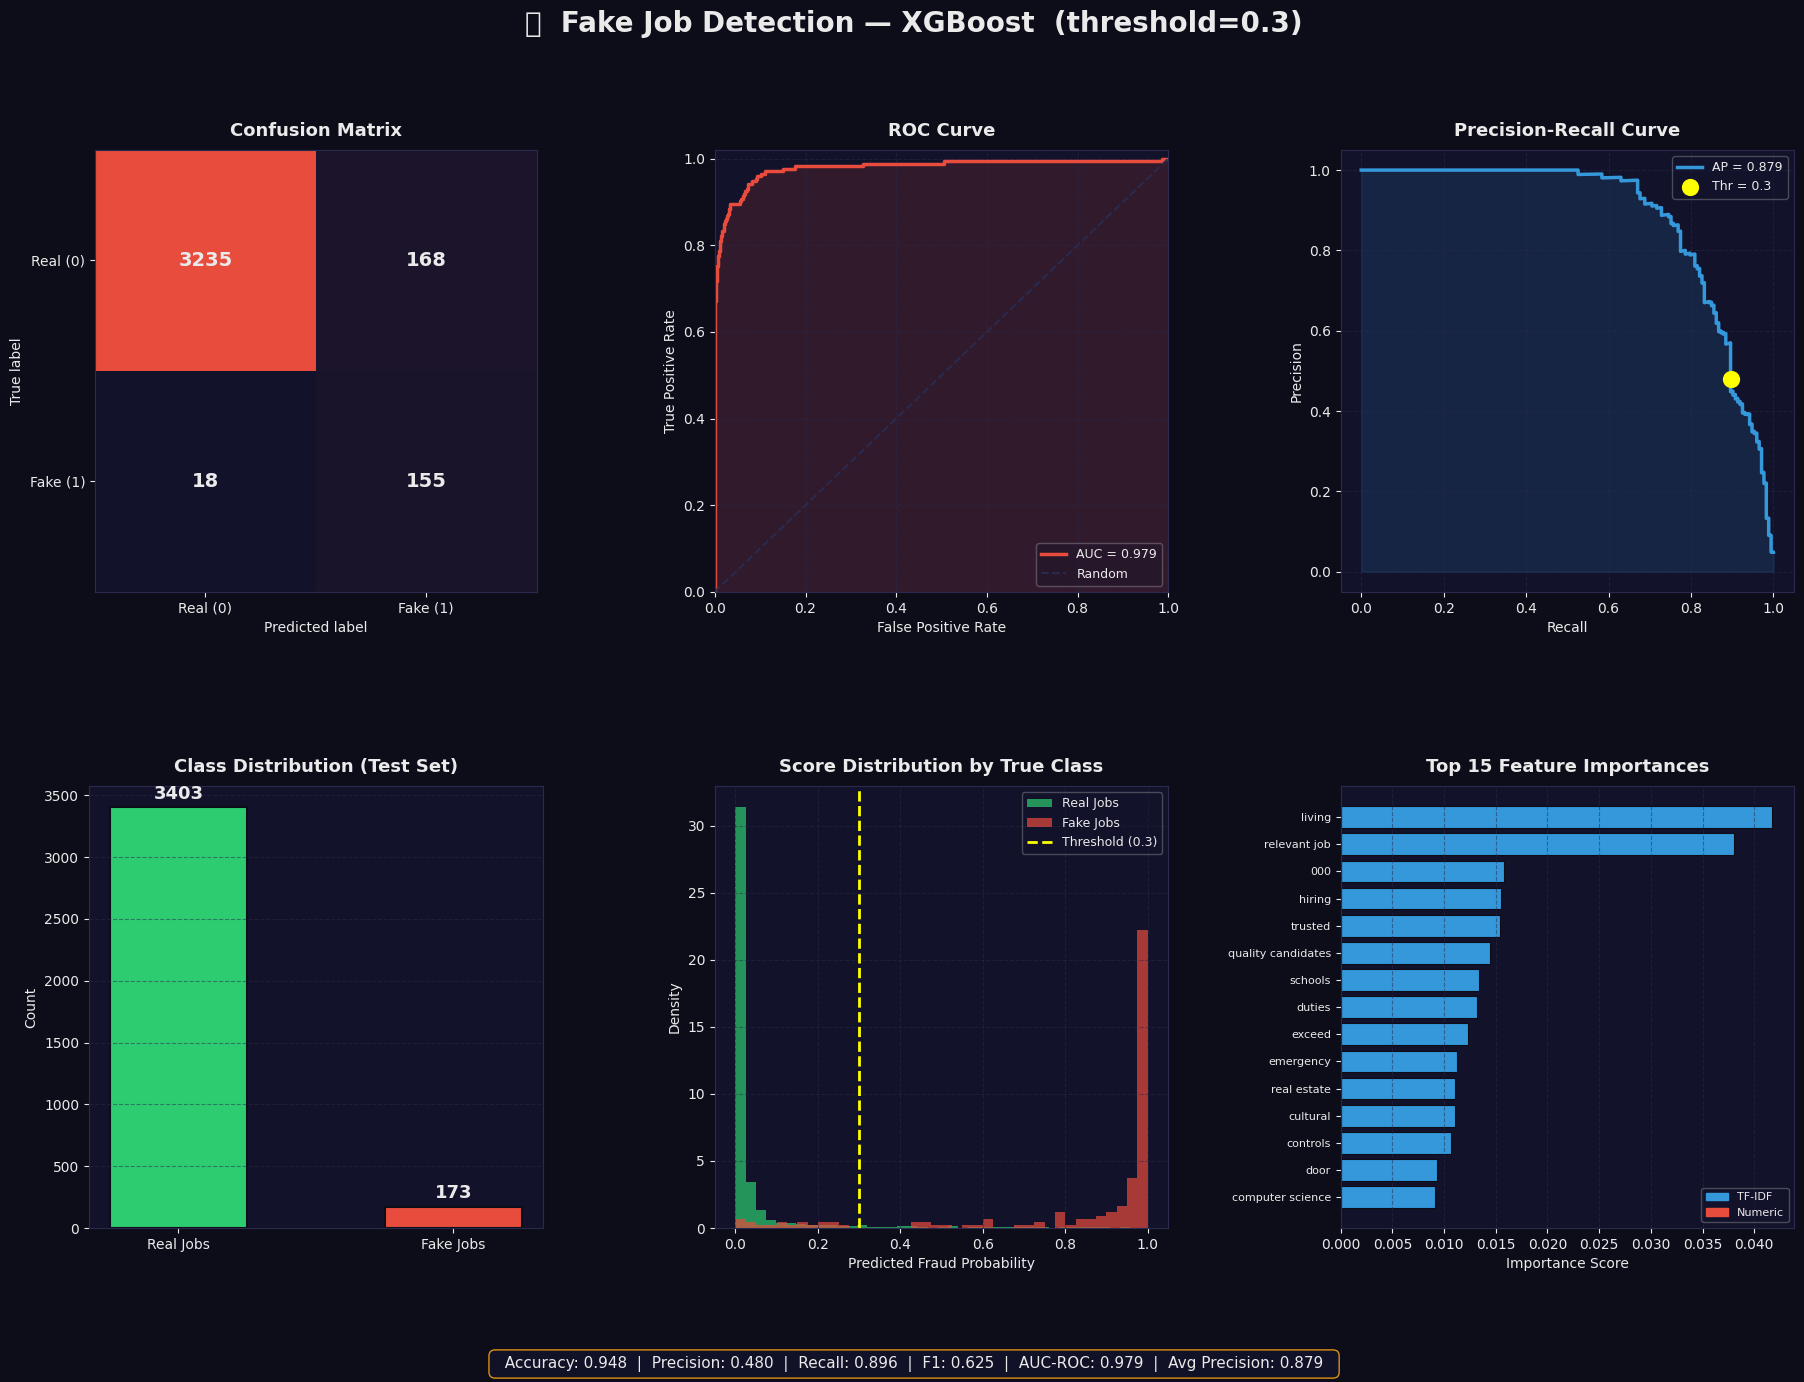

  Saved → xgb_pipeline.pkl

═════════════════════════════════════════════════════════════════
  ⚡  MODEL 3 — AdaBoost
═════════════════════════════════════════════════════════════════
  Training...

--- AdaBoost (threshold=0.3) ---
              precision    recall  f1-score   support

        Real       1.00      0.03      0.07      3403
        Fake       0.05      1.00      0.10       173

    accuracy                           0.08      3576
   macro avg       0.53      0.52      0.08      3576
weighted avg       0.95      0.08      0.07      3576

  ✅  Dashboard saved → dashboard_adaboost.png


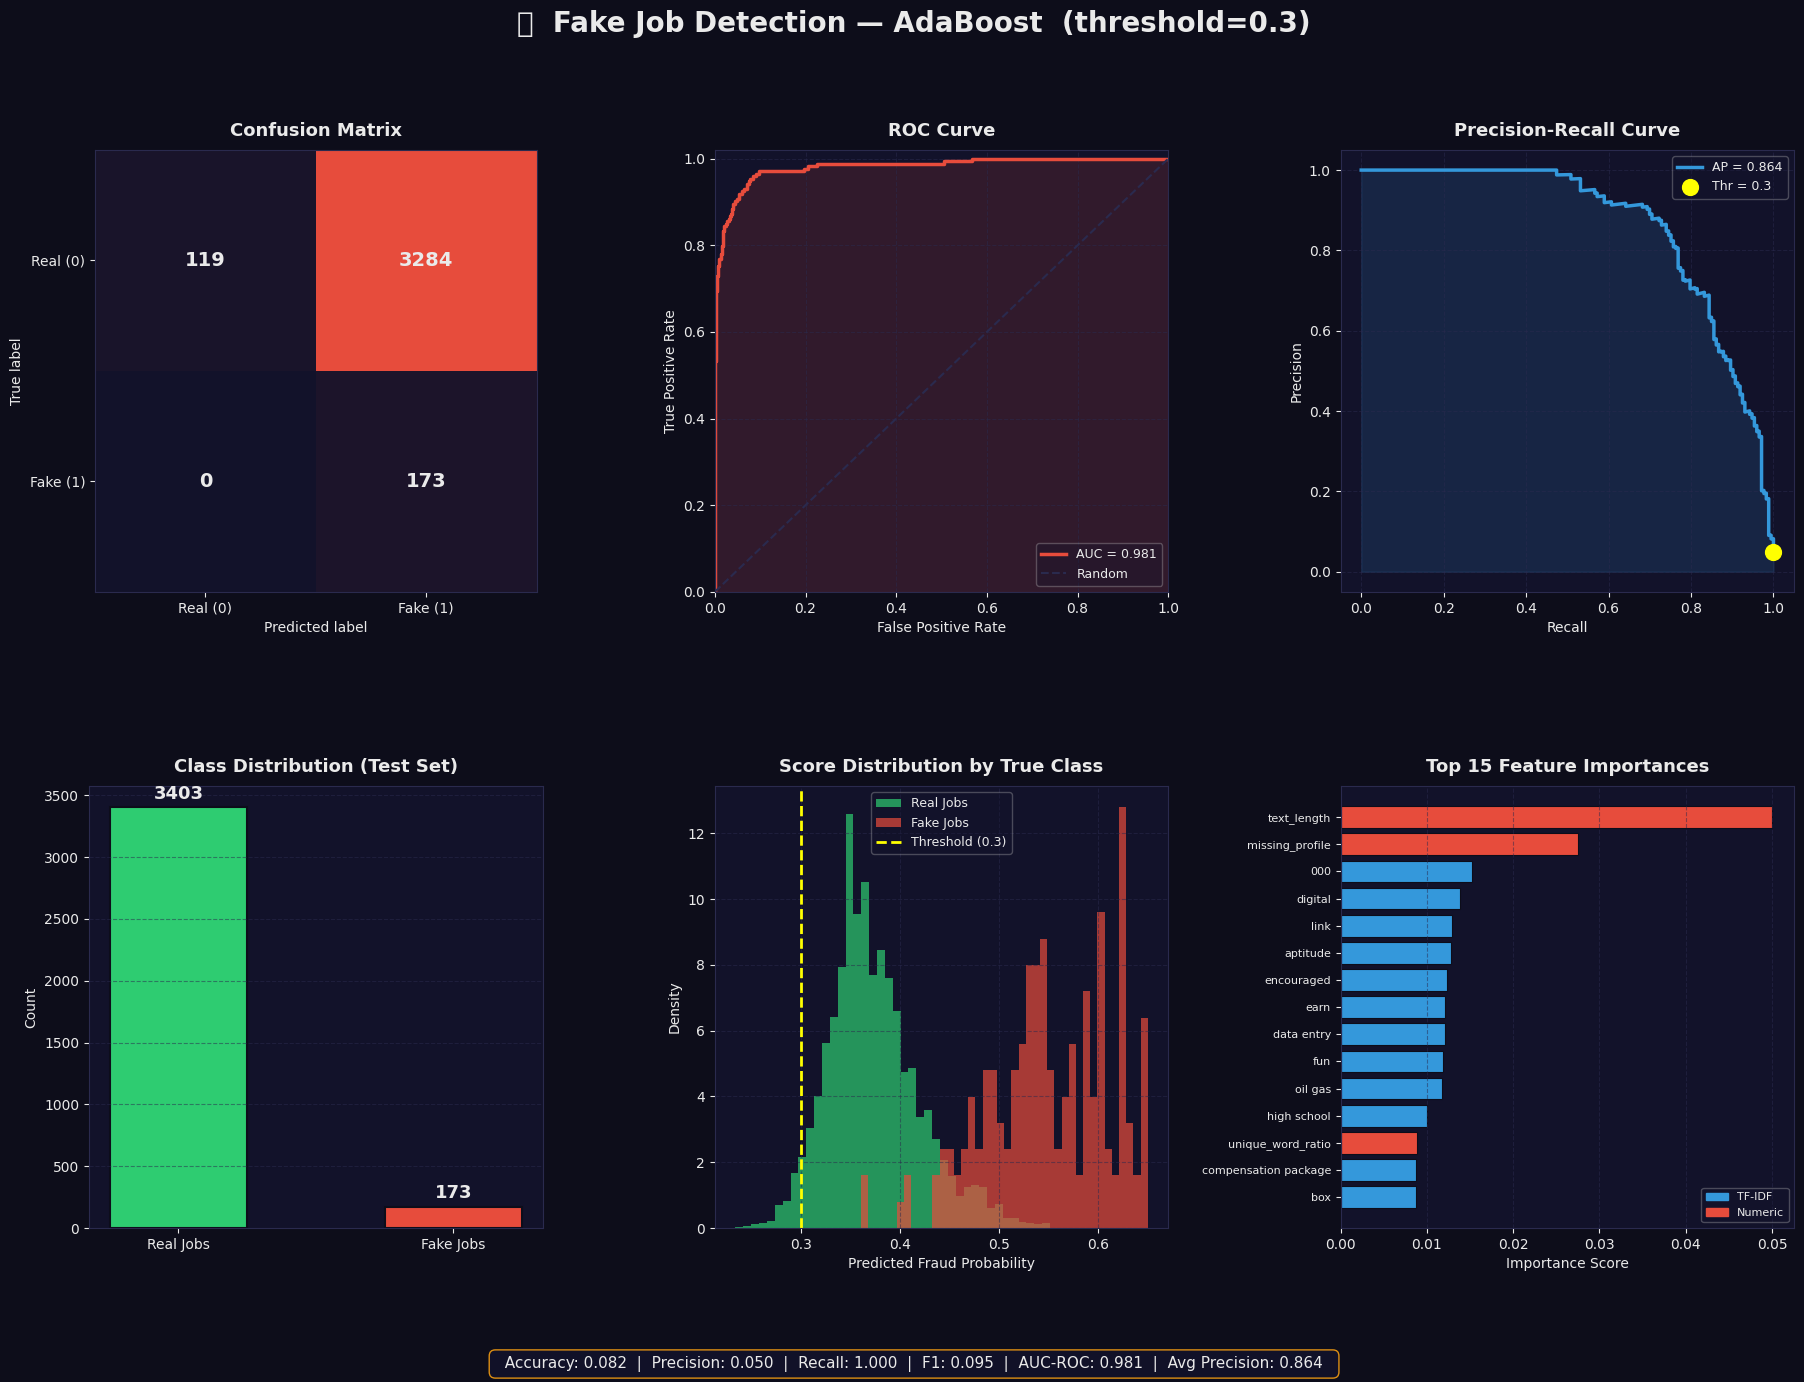

  Saved → ada_pipeline.pkl

═════════════════════════════════════════════════════════════════
  🐱  MODEL 4 — CatBoost
═════════════════════════════════════════════════════════════════
  Training (CatBoost — silent mode)...

--- CatBoost (threshold=0.3) ---
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      3403
        Fake       0.55      0.85      0.67       173

    accuracy                           0.96      3576
   macro avg       0.77      0.91      0.82      3576
weighted avg       0.97      0.96      0.96      3576

  ✅  Dashboard saved → dashboard_catboost.png


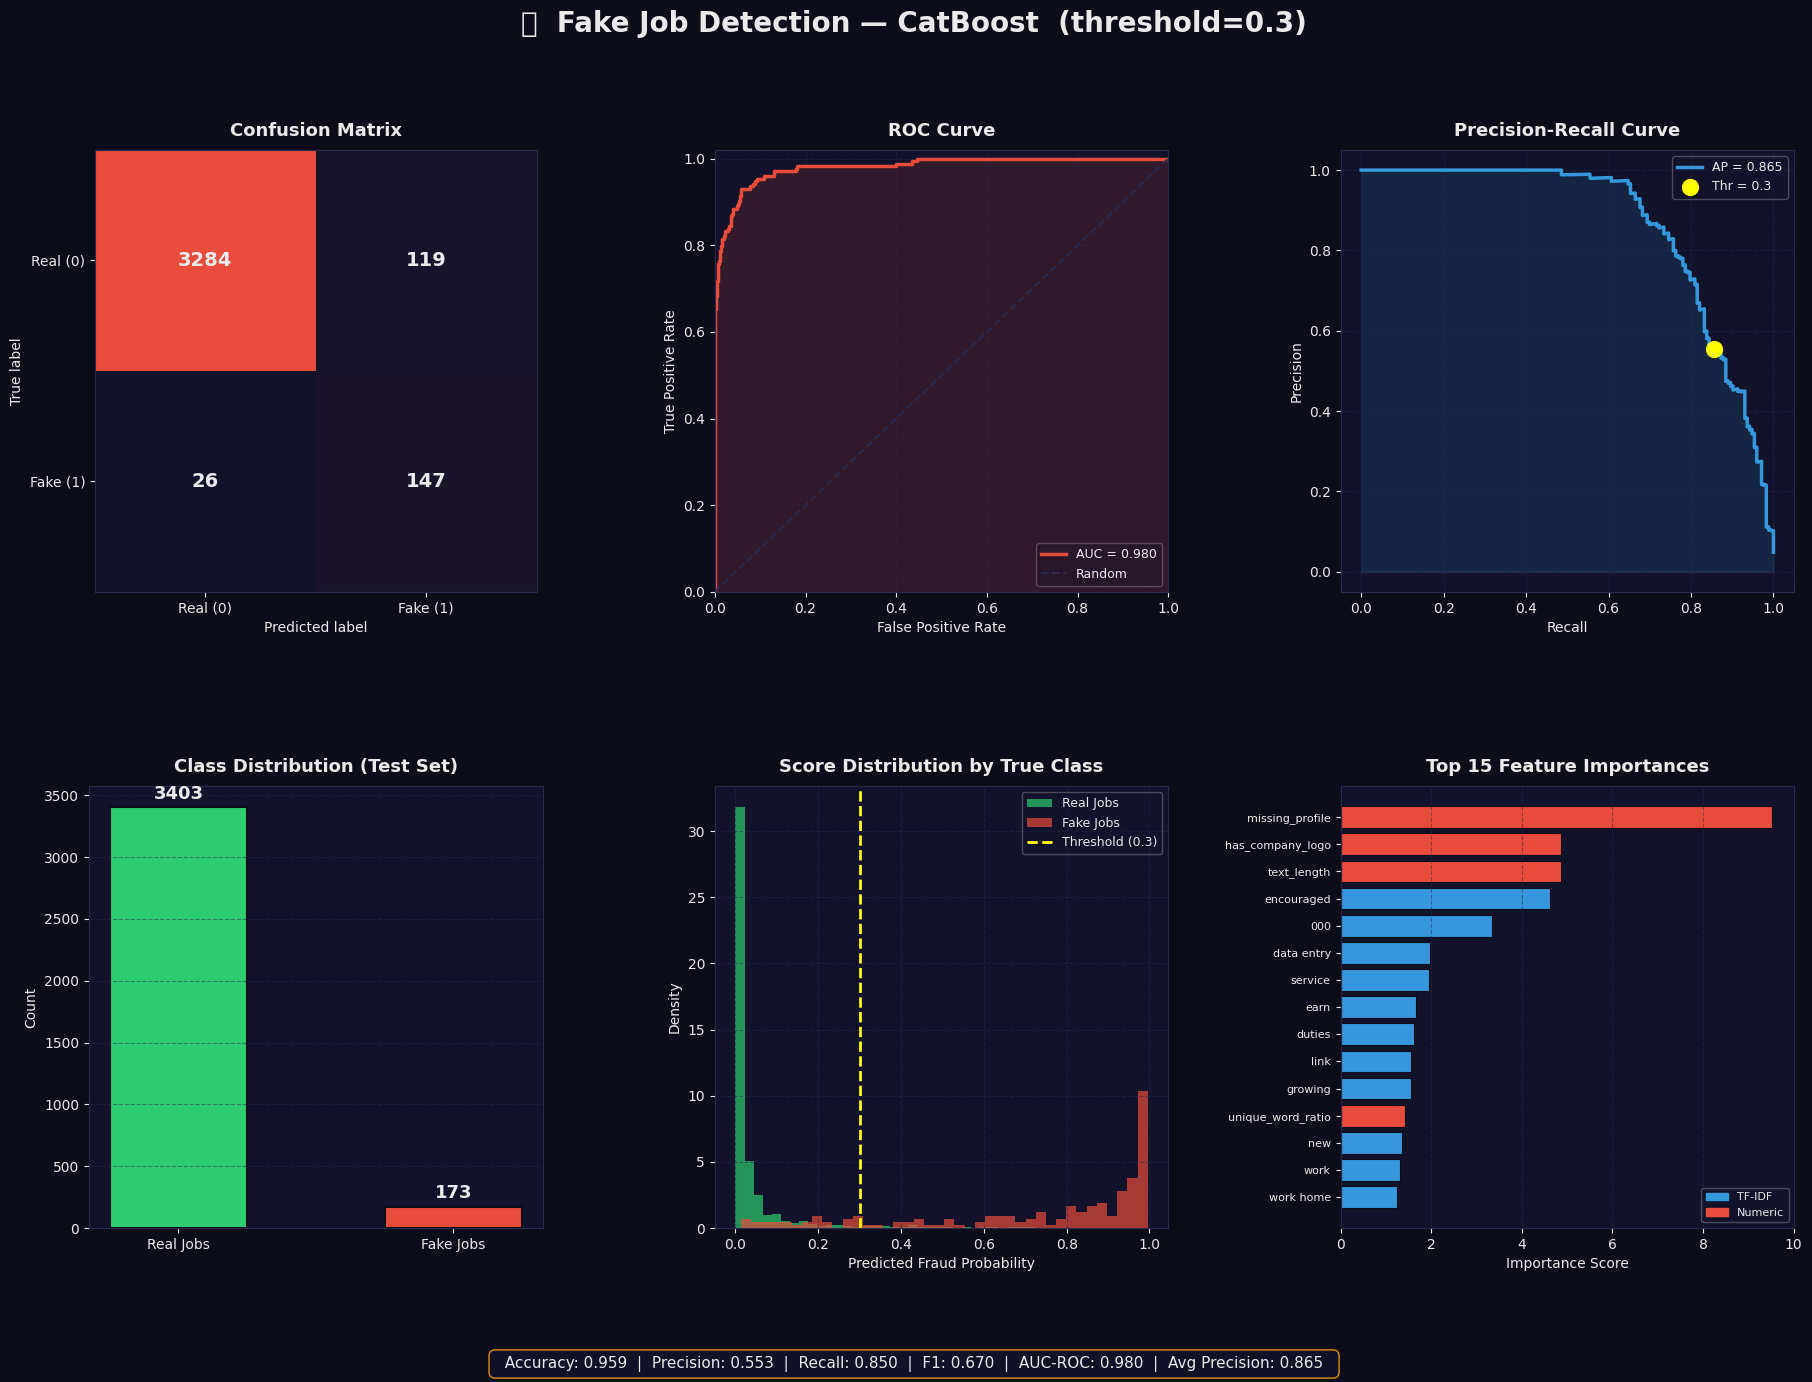

  Saved → catboost_pipeline.pkl

✅  Comparison chart saved → model_comparison_all.png


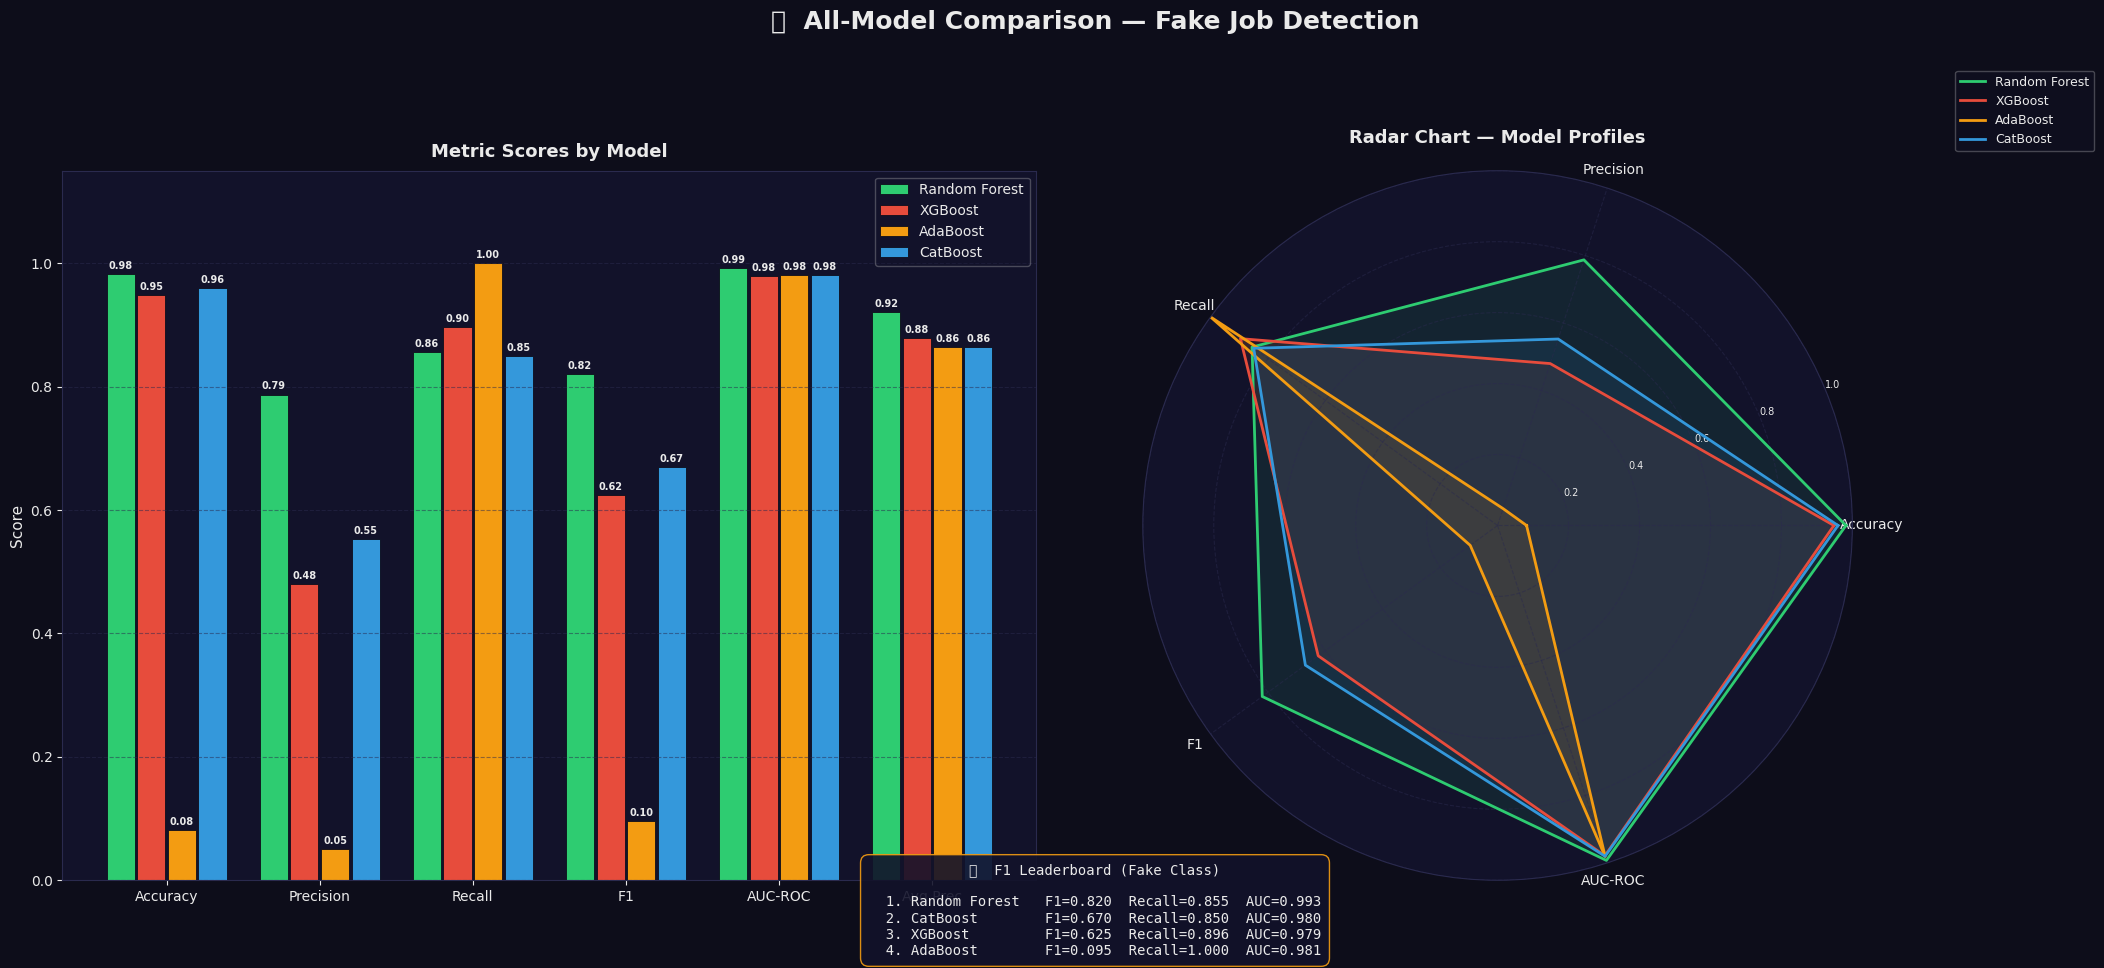


═════════════════════════════════════════════════════════════════
  🧠  EXPLAINABLE AI  (SHAP)
═════════════════════════════════════════════════════════════════

🧠  SHAP XAI → Random Forest


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was -25350520681319032.000000, while the model output was 0.983333. If this difference is acceptable you can set check_additivity=False to disable this check.

In [3]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║          FAKE JOB DETECTION — 4-MODEL ENSEMBLE + XAI (SHAP)                ║
║                                                                              ║
║  Models  : Random Forest | XGBoost | AdaBoost | CatBoost                   ║
║  XAI     : SHAP (TreeExplainer / KernelExplainer)                           ║
║  Outputs : Per-model dashboards, SHAP plots, comparison chart               ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

import pandas as pd
import numpy as np
import warnings
import scipy.sparse as sp
import joblib

warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score,
)

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Boosting libraries ───────────────────────────────────────────────────────
from xgboost import XGBClassifier

# Auto-install catboost if missing
try:
    from catboost import CatBoostClassifier
except ModuleNotFoundError:
    import subprocess, sys
    print("⚙️  CatBoost not found — installing...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier
    print("✅  CatBoost installed successfully!")

# ── XAI ──────────────────────────────────────────────────────────────────────
import shap

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap


# ═══════════════════════════════════════════════════════════════════════════════
#  GLOBAL COLOUR PALETTE
# ═══════════════════════════════════════════════════════════════════════════════
REAL_COLOR  = '#2ecc71'
FAKE_COLOR  = '#e74c3c'
ACCENT      = '#f39c12'
BLUE        = '#3498db'
PURPLE      = '#9b59b6'
TEAL        = '#1abc9c'
BG          = '#0d0d1a'
PANEL_BG    = '#12122a'
TEXT        = '#eaeaea'
GRID        = '#2a2a4e'

# One distinct colour per model (used in comparison chart)
MODEL_COLORS = {
    'Random Forest': REAL_COLOR,
    'XGBoost':       FAKE_COLOR,
    'AdaBoost':      ACCENT,
    'CatBoost':      BLUE,
}

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL_BG,
    'axes.edgecolor':   GRID,
    'axes.labelcolor':  TEXT,
    'xtick.color':      TEXT,
    'ytick.color':      TEXT,
    'text.color':       TEXT,
    'grid.color':       GRID,
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})


# ═══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════
def load_data(filepath: str = 'job_dataset.csv') -> pd.DataFrame | None:
    try:
        df = pd.read_csv(filepath)
        print(f"✅  Loaded: {filepath}  |  Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"❌  File not found: {filepath}")
        return None


# ═══════════════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════
SUSPICIOUS_KEYWORDS = [
    'urgent', 'hiring now', 'no experience', 'easy money',
    'work from home', '$$$', 'guaranteed', 'investment',
    'weekly pay', 'unlimited income', 'be your own boss',
    'financial freedom', 'multi-level', 'mlm', 'wire transfer',
    'cryptocurrency', 'upfront fee', 'processing fee',
]


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].fillna('')

    available = [c for c in text_cols if c in df.columns]
    df['full_text'] = df[available].apply(lambda r: ' '.join(r.values), axis=1)

    def count_suspicious(text: str) -> int:
        t = text.lower()
        return sum(1 for kw in SUSPICIOUS_KEYWORDS if kw in t)

    df['suspicious_word_count'] = df['full_text'].apply(count_suspicious)
    df['missing_profile']       = (df['company_profile'] == '').astype(int) \
                                   if 'company_profile' in df.columns else 0
    df['missing_requirements']  = (df['requirements'] == '').astype(int) \
                                   if 'requirements' in df.columns else 0
    df['text_length']           = df['full_text'].apply(len)
    df['exclamation_count']     = df['full_text'].apply(lambda t: t.count('!'))
    df['caps_ratio']            = df['full_text'].apply(
        lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
    df['avg_word_length']       = df['full_text'].apply(
        lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)
    df['unique_word_ratio']     = df['full_text'].apply(
        lambda t: len(set(t.lower().split())) / max(len(t.split()), 1))

    return df


# ═══════════════════════════════════════════════════════════════════════════════
#  SHARED PREPROCESSOR
# ═══════════════════════════════════════════════════════════════════════════════
def build_preprocessor(text_feature: str, num_features: list) -> ColumnTransformer:
    return ColumnTransformer(transformers=[
        ('text', TfidfVectorizer(
            stop_words   = 'english',
            max_features = 3000,
            ngram_range  = (1, 2),
            sublinear_tf = True,
        ), text_feature),
        ('num', StandardScaler(), num_features),
    ])


# ═══════════════════════════════════════════════════════════════════════════════
#  PER-MODEL EVALUATION DASHBOARD  (6-panel)
# ═══════════════════════════════════════════════════════════════════════════════
def visualize_results(y_test, y_pred, y_prob, threshold: float,
                      model_name: str, num_features: list, pipeline) -> dict:
    """Draws and saves a 6-panel dashboard. Returns dict of scalar metrics."""

    fig = plt.figure(figsize=(22, 14), facecolor=BG)
    fig.suptitle(f'🔍  Fake Job Detection — {model_name}  (threshold={threshold})',
                 fontsize=20, fontweight='bold', color=TEXT, y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.44, wspace=0.38)

    # ── 1. Confusion Matrix ────────────────────────────────────────────────
    ax1  = fig.add_subplot(gs[0, 0])
    cm   = confusion_matrix(y_test, y_pred)
    cmap = LinearSegmentedColormap.from_list('rg', [PANEL_BG, FAKE_COLOR], N=256)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Real (0)', 'Fake (1)'])
    disp.plot(ax=ax1, cmap=cmap, colorbar=False)
    ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
    for txt in disp.text_.ravel():
        txt.set_color(TEXT); txt.set_fontsize(14); txt.set_fontweight('bold')

    # ── 2. ROC Curve ──────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=FAKE_COLOR, lw=2.5, label=f'AUC = {roc_auc:.3f}')
    ax2.plot([0, 1], [0, 1], color=GRID, lw=1.5, linestyle='--', label='Random')
    ax2.fill_between(fpr, tpr, alpha=0.15, color=FAKE_COLOR)
    ax2.set(xlim=[0, 1], ylim=[0, 1.02], xlabel='False Positive Rate',
            ylabel='True Positive Rate')
    ax2.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=10)
    ax2.legend(fontsize=9, framealpha=0.3); ax2.grid(True)

    # ── 3. Precision-Recall Curve ──────────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    prec, rec, thr_pr = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax3.plot(rec, prec, color=BLUE, lw=2.5, label=f'AP = {ap:.3f}')
    ax3.fill_between(rec, prec, alpha=0.15, color=BLUE)
    idx = np.argmin(np.abs(thr_pr - threshold))
    ax3.scatter(rec[idx], prec[idx], color='yellow', zorder=5, s=130,
                label=f'Thr = {threshold}')
    ax3.set(xlabel='Recall', ylabel='Precision')
    ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=10)
    ax3.legend(fontsize=9, framealpha=0.3); ax3.grid(True)

    # ── 4. Class Distribution ──────────────────────────────────────────────
    ax4    = fig.add_subplot(gs[1, 0])
    counts = [(y_test == 0).sum(), (y_test == 1).sum()]
    bars   = ax4.bar(['Real Jobs', 'Fake Jobs'], counts,
                     color=[REAL_COLOR, FAKE_COLOR], width=0.5,
                     edgecolor=BG, linewidth=1.5)
    for bar, c in zip(bars, counts):
        ax4.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 str(c), ha='center', va='bottom',
                 fontsize=13, fontweight='bold', color=TEXT)
    ax4.set_title('Class Distribution (Test Set)', fontsize=13,
                  fontweight='bold', pad=10)
    ax4.set_ylabel('Count'); ax4.grid(axis='y')

    # ── 5. Score Distribution ──────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(y_prob[y_test == 0], bins=40, alpha=0.7,
             color=REAL_COLOR, label='Real Jobs', density=True)
    ax5.hist(y_prob[y_test == 1], bins=40, alpha=0.7,
             color=FAKE_COLOR, label='Fake Jobs', density=True)
    ax5.axvline(threshold, color='yellow', linestyle='--', lw=2,
                label=f'Threshold ({threshold})')
    ax5.set(xlabel='Predicted Fraud Probability', ylabel='Density')
    ax5.set_title('Score Distribution by True Class', fontsize=13,
                  fontweight='bold', pad=10)
    ax5.legend(fontsize=9, framealpha=0.3); ax5.grid(True)

    # ── 6. Feature Importances ─────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    try:
        clf         = pipeline.named_steps['classifier']
        pre         = pipeline.named_steps['preprocessor']
        tfidf_names = pre.named_transformers_['text'].get_feature_names_out().tolist()
        all_names   = tfidf_names + num_features

        if hasattr(clf, 'feature_importances_'):
            imps = clf.feature_importances_
        elif hasattr(clf, 'coef_'):
            imps = np.abs(clf.coef_[0])
        else:
            raise AttributeError('No importances found')

        top_n   = 15
        indices = np.argsort(imps)[-top_n:][::-1]
        top_imp = imps[indices]
        top_lbl = [all_names[i] if i < len(all_names) else f'feat_{i}'
                   for i in indices]
        bar_cols = [FAKE_COLOR if i >= len(tfidf_names) else BLUE
                    for i in indices]

        ax6.barh(range(top_n), top_imp[::-1], color=bar_cols[::-1],
                 edgecolor=BG, linewidth=0.8)
        ax6.set_yticks(range(top_n))
        ax6.set_yticklabels(top_lbl[::-1], fontsize=8)
        ax6.set_xlabel('Importance Score')
        ax6.set_title(f'Top {top_n} Feature Importances', fontsize=13,
                      fontweight='bold', pad=10)
        ax6.legend(handles=[
            mpatches.Patch(color=BLUE,       label='TF-IDF'),
            mpatches.Patch(color=FAKE_COLOR, label='Numeric'),
        ], fontsize=8, framealpha=0.3)
        ax6.grid(axis='x')
    except Exception as e:
        ax6.text(0.5, 0.5, f'Importances unavailable:\n{e}',
                 ha='center', va='center', transform=ax6.transAxes, color=TEXT)

    # ── Summary strip ──────────────────────────────────────────────────────
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    summary = (f"  Accuracy: {acc:.3f}  |  Precision: {prec:.3f}  |"
               f"  Recall: {rec:.3f}  |  F1: {f1:.3f}  |"
               f"  AUC-ROC: {roc_auc:.3f}  |  Avg Precision: {ap:.3f}  ")
    fig.text(0.5, 0.01, summary, ha='center', fontsize=11, color=TEXT,
             bbox=dict(boxstyle='round,pad=0.4', facecolor=PANEL_BG,
                       edgecolor=ACCENT, alpha=0.9))

    fname = f'dashboard_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"  ✅  Dashboard saved → {fname}")
    plt.show()

    return dict(Accuracy=acc, Precision=prec, Recall=rec,
                F1=f1, AUC_ROC=roc_auc, Avg_Precision=ap)


# ═══════════════════════════════════════════════════════════════════════════════
#  XAI — SHAP EXPLANATIONS
# ═══════════════════════════════════════════════════════════════════════════════
def explain_with_shap(pipeline, X_train, X_test, num_features: list,
                      model_name: str, max_display: int = 20,
                      n_background: int = 200, n_explain: int = 500):
    """
    Generates 3 SHAP plots:
      1. Beeswarm  — impact of each feature across samples
      2. Bar       — mean |SHAP| global importance
      3. Waterfall — why the single highest-risk sample was flagged
    """
    print(f"\n🧠  SHAP XAI → {model_name}")

    preprocessor = pipeline.named_steps['preprocessor']
    clf          = pipeline.named_steps['classifier']

    # Transform (SMOTE was only for training, apply preprocessor directly)
    X_tr_t = preprocessor.transform(X_train)
    X_te_t = preprocessor.transform(X_test)

    if sp.issparse(X_tr_t): X_tr_t = X_tr_t.toarray()
    if sp.issparse(X_te_t): X_te_t = X_te_t.toarray()

    tfidf_names = preprocessor.named_transformers_['text'] \
                              .get_feature_names_out().tolist()
    all_names   = tfidf_names + num_features

    # Sub-sample
    bg_idx  = np.random.choice(X_tr_t.shape[0],
                                min(n_background, X_tr_t.shape[0]), replace=False)
    ex_idx  = np.random.choice(X_te_t.shape[0],
                                min(n_explain,    X_te_t.shape[0]),  replace=False)
    background = X_tr_t[bg_idx]
    X_explain  = X_te_t[ex_idx]

    # ── Choose explainer based on model type ──────────────────────────────
    if isinstance(clf, (XGBClassifier, RandomForestClassifier, CatBoostClassifier)):
        explainer   = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_explain)
        # RF returns list [class0, class1]; XGB/CB return single array
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
        base_val = (explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value)
    else:
        # AdaBoost — model-agnostic KernelExplainer
        print("  (AdaBoost → KernelExplainer; using small subset for speed...)")
        predict_fn  = lambda x: clf.predict_proba(x)[:, 1]
        explainer   = shap.KernelExplainer(predict_fn, background[:50])
        X_explain   = X_explain[:100]
        shap_values = explainer.shap_values(X_explain, nsamples=100)
        sv          = shap_values
        base_val    = float(explainer.expected_value)

    def _style_shap_fig():
        fig = plt.gcf()
        fig.set_facecolor(BG)
        for ax in fig.axes:
            ax.set_facecolor(PANEL_BG)
            ax.tick_params(colors=TEXT)
            for lbl in [ax.xaxis.label, ax.yaxis.label, ax.title]:
                lbl.set_color(TEXT)

    # ── Plot 1: Beeswarm ───────────────────────────────────────────────────
    plt.figure(figsize=(14, 8), facecolor=BG)
    plt.title(f'SHAP Beeswarm — {model_name}',
              fontsize=15, fontweight='bold', color=TEXT, pad=12)
    shap.summary_plot(sv, X_explain, feature_names=all_names,
                      max_display=max_display, show=False)
    _style_shap_fig()
    fname = f'shap_beeswarm_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"  ✅  {fname}")
    plt.show()

    # ── Plot 2: Bar ────────────────────────────────────────────────────────
    plt.figure(figsize=(12, 7), facecolor=BG)
    plt.title(f'SHAP Mean |Value| — {model_name}',
              fontsize=15, fontweight='bold', color=TEXT, pad=12)
    shap.summary_plot(sv, X_explain, feature_names=all_names,
                      plot_type='bar', max_display=max_display, show=False)
    _style_shap_fig()
    fname = f'shap_bar_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"  ✅  {fname}")
    plt.show()

    # ── Plot 3: Waterfall for highest-risk sample ──────────────────────────
    risk_idx = np.argmax(sv.sum(axis=1))
    exp_obj  = shap.Explanation(
        values       = sv[risk_idx],
        base_values  = base_val,
        data         = X_explain[risk_idx],
        feature_names= all_names,
    )
    plt.figure(figsize=(14, 8), facecolor=BG)
    shap.waterfall_plot(exp_obj, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Highest-Risk Sample ({model_name})',
              fontsize=14, fontweight='bold', color=TEXT, pad=12)
    _style_shap_fig()
    fname = f'shap_waterfall_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"  ✅  {fname}")
    plt.show()

    print(f"  SHAP done for {model_name}.\n")


# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL BUILDERS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Random Forest ──────────────────────────────────────────────────────────
def build_random_forest(X_train, X_test, y_train, y_test,
                         text_feature, num_features, threshold=0.30):
    print("\n" + "═"*65)
    print("  🌲  MODEL 1 — Random Forest")
    print("═"*65)

    pipeline = ImbPipeline([
        ('preprocessor', build_preprocessor(text_feature, num_features)),
        ('smote',        SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier',   RandomForestClassifier(
            n_estimators  = 300,
            max_depth     = None,
            class_weight  = 'balanced_subsample',
            n_jobs        = -1,
            random_state  = 42,
        )),
    ])

    print("  Training...")
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n--- Random Forest (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=['Real', 'Fake']))

    metrics = visualize_results(y_test, y_pred, y_prob, threshold,
                                'Random Forest', num_features, pipeline)
    joblib.dump(pipeline, 'rf_pipeline.pkl')
    print("  Saved → rf_pipeline.pkl")
    return pipeline, metrics


# ── 2. XGBoost ────────────────────────────────────────────────────────────────
def build_xgboost(X_train, X_test, y_train, y_test,
                   text_feature, num_features, threshold=0.30):
    print("\n" + "═"*65)
    print("  🚀  MODEL 2 — XGBoost")
    print("═"*65)

    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    print(f"  scale_pos_weight = {spw:.2f}")

    pipeline = ImbPipeline([
        ('preprocessor', build_preprocessor(text_feature, num_features)),
        ('smote',        SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier',   XGBClassifier(
            n_estimators      = 300,
            max_depth         = 6,
            learning_rate     = 0.05,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            scale_pos_weight  = spw,
            use_label_encoder = False,
            eval_metric       = 'logloss',
            n_jobs            = -1,
            random_state      = 42,
        )),
    ])

    print("  Training...")
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n--- XGBoost (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=['Real', 'Fake']))

    metrics = visualize_results(y_test, y_pred, y_prob, threshold,
                                'XGBoost', num_features, pipeline)
    joblib.dump(pipeline, 'xgb_pipeline.pkl')
    print("  Saved → xgb_pipeline.pkl")
    return pipeline, metrics


# ── 3. AdaBoost ───────────────────────────────────────────────────────────────
def build_adaboost(X_train, X_test, y_train, y_test,
                    text_feature, num_features, threshold=0.30):
    print("\n" + "═"*65)
    print("  ⚡  MODEL 3 — AdaBoost")
    print("═"*65)

    base = DecisionTreeClassifier(
        max_depth=3, class_weight='balanced', random_state=42)

    pipeline = ImbPipeline([
        ('preprocessor', build_preprocessor(text_feature, num_features)),
        ('smote',        SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier',   AdaBoostClassifier(
            estimator    = base,
            n_estimators = 200,
            learning_rate= 0.5,
            algorithm    = 'SAMME',
            random_state = 42,
        )),
    ])

    print("  Training...")
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n--- AdaBoost (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=['Real', 'Fake']))

    metrics = visualize_results(y_test, y_pred, y_prob, threshold,
                                'AdaBoost', num_features, pipeline)
    joblib.dump(pipeline, 'ada_pipeline.pkl')
    print("  Saved → ada_pipeline.pkl")
    return pipeline, metrics


# ── 4. CatBoost ───────────────────────────────────────────────────────────────
def build_catboost(X_train, X_test, y_train, y_test,
                    text_feature, num_features, threshold=0.30):
    print("\n" + "═"*65)
    print("  🐱  MODEL 4 — CatBoost")
    print("═"*65)

    # CatBoost handles class imbalance natively via auto_class_weights
    pipeline = ImbPipeline([
        ('preprocessor', build_preprocessor(text_feature, num_features)),
        ('smote',        SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier',   CatBoostClassifier(
            iterations        = 300,
            depth             = 6,
            learning_rate     = 0.05,
            auto_class_weights= 'Balanced',
            eval_metric       = 'F1',
            random_seed       = 42,
            verbose           = 0,          # silent training
        )),
    ])

    print("  Training (CatBoost — silent mode)...")
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n--- CatBoost (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=['Real', 'Fake']))

    metrics = visualize_results(y_test, y_pred, y_prob, threshold,
                                'CatBoost', num_features, pipeline)
    joblib.dump(pipeline, 'catboost_pipeline.pkl')
    print("  Saved → catboost_pipeline.pkl")
    return pipeline, metrics


# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL COMPARISON CHART
# ═══════════════════════════════════════════════════════════════════════════════
def compare_models(results: dict):
    """
    Grouped bar chart + radar chart comparing all 4 models.
    results = { 'Model Name': {'Accuracy': 0.97, 'F1': 0.85, ...}, ... }
    """
    metrics       = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC', 'Avg_Precision']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'Avg Prec']
    model_names   = list(results.keys())
    n_m, n_met    = len(model_names), len(metrics)

    fig = plt.figure(figsize=(22, 9), facecolor=BG)
    fig.suptitle('📊  All-Model Comparison — Fake Job Detection',
                 fontsize=18, fontweight='bold', color=TEXT, y=1.01)

    # ── Left: Grouped bar chart ────────────────────────────────────────────
    ax_bar = fig.add_subplot(1, 2, 1)
    ax_bar.set_facecolor(PANEL_BG)
    x = np.arange(n_met)
    w = 0.8 / n_m

    for i, name in enumerate(model_names):
        scores = [results[name].get(m, 0) for m in metrics]
        offset = i * w - (n_m - 1) * w / 2
        bars   = ax_bar.bar(x + offset, scores,
                            width=w * 0.92,
                            color=MODEL_COLORS.get(name, BLUE),
                            label=name,
                            edgecolor=BG, linewidth=0.6)
        for bar, s in zip(bars, scores):
            ax_bar.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005, f'{s:.2f}',
                        ha='center', va='bottom', fontsize=7,
                        fontweight='bold', color=TEXT)

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(metric_labels, fontsize=10)
    ax_bar.set_ylabel('Score', fontsize=11)
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_title('Metric Scores by Model', fontsize=13,
                     fontweight='bold', pad=10)
    ax_bar.legend(fontsize=10, framealpha=0.3)
    ax_bar.grid(axis='y')

    # ── Right: Radar chart ─────────────────────────────────────────────────
    radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC_ROC']
    radar_labels  = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
    N   = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    ax_radar = fig.add_subplot(1, 2, 2, polar=True)
    ax_radar.set_facecolor(PANEL_BG)
    ax_radar.spines['polar'].set_color(GRID)
    ax_radar.tick_params(colors=TEXT)

    for name in model_names:
        vals = [results[name].get(m, 0) for m in radar_metrics]
        vals += vals[:1]
        color = MODEL_COLORS.get(name, BLUE)
        ax_radar.plot(angles, vals, color=color, lw=2, label=name)
        ax_radar.fill(angles, vals, color=color, alpha=0.1)

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(radar_labels, fontsize=10, color=TEXT)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax_radar.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'],
                              fontsize=7, color=TEXT)
    ax_radar.yaxis.grid(True, color=GRID)
    ax_radar.xaxis.grid(True, color=GRID)
    ax_radar.set_title('Radar Chart — Model Profiles',
                       fontsize=13, fontweight='bold', pad=20, color=TEXT)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                    fontsize=9, framealpha=0.3)

    # ── Leaderboard text box ───────────────────────────────────────────────
    ranked = sorted(results.items(), key=lambda kv: kv[1]['F1'], reverse=True)
    lines  = ['🏆  F1 Leaderboard (Fake Class)\n']
    for rank, (name, vals) in enumerate(ranked, 1):
        lines.append(f"  {rank}. {name:<15} F1={vals['F1']:.3f}  "
                     f"Recall={vals['Recall']:.3f}  AUC={vals['AUC_ROC']:.3f}")
    fig.text(0.5, -0.04, '\n'.join(lines), ha='center', fontsize=10,
             color=TEXT, fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor=PANEL_BG,
                       edgecolor=ACCENT, alpha=0.9))

    plt.tight_layout()
    plt.savefig('model_comparison_all.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    print("\n✅  Comparison chart saved → model_comparison_all.png")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
#  MAIN
# ═══════════════════════════════════════════════════════════════════════════════
def main():
    THRESHOLD = 0.30    # Lower = catch more scams (higher recall, more false positives)
    RUN_XAI   = True    # Set False to skip SHAP (much faster)

    # ── Load & engineer ────────────────────────────────────────────────────
    df = load_data('job_dataset.csv')
    if df is None:
        return

    df = engineer_features(df)

    text_feature = 'full_text'
    num_features = [
        'suspicious_word_count', 'missing_profile', 'missing_requirements',
        'text_length', 'exclamation_count', 'caps_ratio',
        'avg_word_length', 'unique_word_ratio',
    ]
    for col in ['has_company_logo', 'telecommuting']:
        if col in df.columns:
            num_features.append(col)

    df[num_features] = df[num_features].fillna(0)

    X = df[[text_feature] + num_features]
    y = df['fraudulent'] if 'fraudulent' in df.columns else np.zeros(len(df))

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
    print(f"Fraud rate — train: {y_train.mean():.3%}  | test: {y_test.mean():.3%}\n")

    # ── Train all 4 models ─────────────────────────────────────────────────
    rf_pipe,  rf_metrics  = build_random_forest(
        X_train, X_test, y_train, y_test, text_feature, num_features, THRESHOLD)

    xgb_pipe, xgb_metrics = build_xgboost(
        X_train, X_test, y_train, y_test, text_feature, num_features, THRESHOLD)

    ada_pipe, ada_metrics = build_adaboost(
        X_train, X_test, y_train, y_test, text_feature, num_features, THRESHOLD)

    cat_pipe, cat_metrics = build_catboost(
        X_train, X_test, y_train, y_test, text_feature, num_features, THRESHOLD)

    # ── Comparison ─────────────────────────────────────────────────────────
    all_results = {
        'Random Forest': rf_metrics,
        'XGBoost':       xgb_metrics,
        'AdaBoost':      ada_metrics,
        'CatBoost':      cat_metrics,
    }
    compare_models(all_results)

    # ── SHAP XAI ───────────────────────────────────────────────────────────
    if RUN_XAI:
        print("\n" + "═"*65)
        print("  🧠  EXPLAINABLE AI  (SHAP)")
        print("═"*65)

        # TreeExplainer — fast, exact, works for RF / XGBoost / CatBoost
        for name, pipe in [('Random Forest', rf_pipe),
                            ('XGBoost',       xgb_pipe),
                            ('CatBoost',      cat_pipe)]:
            explain_with_shap(pipe, X_train, X_test, num_features, name,
                              max_display=20, n_background=200, n_explain=500)

        # KernelExplainer — model-agnostic (slow), used for AdaBoost
        explain_with_shap(ada_pipe, X_train, X_test, num_features, 'AdaBoost',
                          max_display=20, n_background=100, n_explain=100)

    print("\n✅  All done!  Generated files:")
    print("   • dashboard_*.png          — per-model evaluation dashboards")
    print("   • shap_beeswarm_*.png      — SHAP feature impact (dot plot)")
    print("   • shap_bar_*.png           — SHAP global importance (bar)")
    print("   • shap_waterfall_*.png     — SHAP explanation for riskiest sample")
    print("   • model_comparison_all.png — side-by-side comparison + radar")
    print("   • *_pipeline.pkl           — saved model pipelines\n")


if __name__ == '__main__':
    main()